In [2]:
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
import re
import lightgbm as lgb
import xgboost as xgb
import shap
import optuna
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

c:\Users\Smaa Hossam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def mohra_raneem_features(df):
    df = df.copy()

    binary_text_columns = ['SupportURL', 'SupportEmail', 'Website', 'ExtUserAcctNotice',
                           'DRMNotice', 'Background', 'HeaderImage','LegalNotice','IsFree','FreeVerAvail','PlatformMac','PlatformLinux','PlatformWindows',
                           'GenreIsMassivelyMultiplayer','GenreIsRacing','GenreIsSports','GenreIsFreeToPlay','GenreIsEarlyAccess','GenreIsSimulation',
                           'GenreIsRPG','GenreIsStrategy','GenreIsCasual','GenreIsAdventure','GenreIsAction','GenreIsIndie','GenreIsNonGame''CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO']
    for col in binary_text_columns:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str).str.strip().ne('').astype(int)




    # Reviews → extract sentiment signals instead of just binary
    if 'Reviews' in df.columns:
        positive_words = ['great', 'amazing', 'fun', 'recommend', 'excellent', 'love', 'best', 'fantastic', 'perfect', 'good']
        negative_words = ['bad', 'terrible', 'boring', 'waste', 'buggy', 'broken', 'awful', 'worst', 'crash', 'disappointment']
        df['Review_Has_Content'] = df['Reviews'].fillna('').astype(str).str.strip().ne('').astype(int)
        df['Review_Positive_Signals'] = df['Reviews'].apply(
            lambda x: sum(w in str(x).lower() for w in positive_words) if isinstance(x, str) else 0
        )
        df['Review_Negative_Signals'] = df['Reviews'].apply(
            lambda x: sum(w in str(x).lower() for w in negative_words) if isinstance(x, str) else 0
        )
        df['Review_Sentiment_Score'] = df['Review_Positive_Signals'] - df['Review_Negative_Signals']
        df.drop(columns=['Reviews'], inplace=True)



    # Text length features
    textto_num_cols = ['DetailedDescrip', 'AboutText', 'ShortDescrip']
    for col in textto_num_cols:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str).str.len()



    common_langs = ['English', 'French', 'German', 'Italian', 'Spanish', 'Korean', 'Japanese', 'Russian', 'Turkish',
                    'Thai', 'Portuguese', 'Polish', 'Dutch', 'Arabic', 'Simplified Chinese', 'Traditional Chinese',
                    'Czech', 'Hungarian', 'Romanian']

    if 'SupportedLanguages' in df.columns:
        df['NumLanguages'] = df['SupportedLanguages'].apply(
            lambda x: sum(1 for l in common_langs if isinstance(x, str) and l in x)
        )
        # has major Asian language support
        asian_langs = ['Korean', 'Japanese', 'Simplified Chinese', 'Traditional Chinese']
        df['Has_Asian_Languages'] = df['SupportedLanguages'].apply(
            lambda x: int(any(l in str(x) for l in asian_langs))
        )

    bool_cols = df.select_dtypes(include='bool').columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)

    if 'ReleaseDate' in df.columns:
        df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce')
        median_date = df['ReleaseDate'].dropna().median()
        df['ReleaseDate'] = df['ReleaseDate'].fillna(median_date)
        df['ReleaseDate_Year'] = df['ReleaseDate'].dt.year.astype('Int64')
        df['ReleaseDate_Month'] = df['ReleaseDate'].dt.month.astype('Int64')
        df['ReleaseDate_Day'] = df['ReleaseDate'].dt.day.astype('Int64')
        df['GameAge'] = datetime.now().year - df['ReleaseDate_Year']
        #  holiday release window (Nov-Dec = high sales season)
        df['Is_Holiday_Release'] = df['ReleaseDate_Month'].apply(
            lambda x: 1 if x in [11, 12] else 0
        )
        #  Quarter of release
        df['Release_Quarter'] = np.ceil(df['ReleaseDate_Month'] / 3).astype('Int64')

    if 'PriceCurrency' in df.columns:
        df['PriceCurrency'] = df['PriceCurrency'].astype(str).str.strip().replace('', 'USD')
        df['PriceCurrency'] = (df['PriceCurrency'] == 'USD').astype(int)


    def extract_reqs(text):
        if not isinstance(text, str) or not text.strip():
            return {'RAM_GB': None, 'Storage_GB': None, 'CPU_GHz': None, 'OpenGL': None}

        ram = re.findall(r'(\d+)\s*(GB|mb)\s*(?:Memory|RAM)', text, re.IGNORECASE)
        storage = re.findall(r'(\d+)\s*GB\s*Hard\s*Drive', text, re.IGNORECASE)
        ghz = re.findall(r'(\d+\.?\d*)\s*(GHz|mhz)', text, re.IGNORECASE)
        opengl = re.findall(r'OpenGL\s*(\d+\.?\d*)', text, re.IGNORECASE)
        cpu = None
        if ghz:
            value, unit = ghz[0]
            value = float(value)
            if unit.lower() == 'mhz':
                value = value / 1000
            cpu = value

        Ram = None
        if ram:
            value, unit = ram[0]
            value = float(value)
            if unit.lower() == 'mb':
                value = value / 1000
            Ram = value

        return {
            'RAM_GB': Ram,
            'Storage_GB': int(storage[0]) if storage else None,
            'CPU_GHz': cpu,
            'OpenGL': float(opengl[0]) if opengl else None
        }

    if 'LinuxMinReqsText' in df.columns:
        linux = df['LinuxMinReqsText'].apply(extract_reqs).apply(pd.Series)
        linux.columns = ['Linux_RAM_GB', 'Linux_Storage_GB', 'Linux_CPU_GHz', 'Linux_OpenGL']
        df = pd.concat([df, linux], axis=1)

    if 'MacMinReqsText' in df.columns:
        mac = df['MacMinReqsText'].apply(extract_reqs).apply(pd.Series)
        mac.columns = ['Mac_RAM_GB', 'Mac_Storage_GB', 'Mac_CPU_GHz', 'Mac_OpenGL']
        df = pd.concat([df, mac], axis=1)

    if 'PCMinReqsText' in df.columns:
        pc = df['PCMinReqsText'].apply(extract_reqs).apply(pd.Series)
        pc.columns = ['PC_RAM_GB', 'PC_Storage_GB', 'PC_CPU_GHz', 'PC_OpenGL']
        df = pd.concat([df, pc], axis=1)

    extract_cols = ['RAM_GB', 'Storage_GB', 'CPU_GHz', 'OpenGL']
    for col in extract_cols:
        linux_col = 'Linux_' + col
        mac_col = 'Mac_' + col
        pc_col = 'PC_' + col

        if linux_col in df.columns and df[linux_col].notna().any():
            df[linux_col] = df[linux_col].fillna(df[linux_col].min())

        if mac_col in df.columns and df[mac_col].notna().any():
            df[mac_col] = df[mac_col].fillna(df[mac_col].min())

        if pc_col in df.columns and df[pc_col].notna().any():
            df[pc_col] = df[pc_col].fillna(df[pc_col].min())
    # fill QueryName columns nulls with unkown
    df['QueryName'] = df['QueryName'].fillna('unknown')
    df=df.drop(columns=['LinuxMinReqsText','LinuxRecReqsText','MacMinReqsText','MacRecReqsText','PCMinReqsText','PCRecReqsText','QueryName','ResponseName','QueryID','ResponseID','SupportedLanguages', 'ReleaseDate'])
    label_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['GamePopularity'] = df['GamePopularity'].map(label_map)
    
    return df



In [4]:
def abd_al_karem_features(df):
    df = df.copy()

    df['Total_Media_Assets'] =np.log1p(df['ScreenshotCount'] + df['MovieCount'])
    df['ScreenshotCount_Log'] = np.log1p(df['ScreenshotCount'])
    df['MovieCount_Log'] = np.log1p(df['MovieCount'])

    df['Total_Media_Assets_log']=np.log1p(df['Total_Media_Assets'])

    conditions_media = [
        (df['Total_Media_Assets'] == 0),
        (df['ScreenshotCount'] < 10) & (df['MovieCount'] <= 1),
        (df['ScreenshotCount'] <= 15) & (df['MovieCount'] <= 2)
    ]
    choices_media = [0, 1, 2]
    df['Marketing_Tier'] = np.select(conditions_media, choices_media, default=3)
    df['Is_Blockbuster'] = (df['MovieCount'] >= 3).astype(int)

    if 'GenreIsNonGame' in df.columns:
        df['Is_NonGame_Flag'] = df['GenreIsNonGame'].astype(int)

    df['Zero_Owners_Flag'] = (df['SteamSpyOwners'] == 0).astype(int)

    df['Has_Demo'] = (df['DemoCount'] > 0).astype(int)
    if 'DemoCount' in df.columns:
        df.drop(columns=['DemoCount'], inplace=True)

    conditions_pkg = [
        (df['PackageCount'] == 0),
        (df['PackageCount'] == 1),
        (df['PackageCount'] >= 2)
    ]
    choices_pkg = [0, 1, 2]
    df['Package_Tier'] = np.select(conditions_pkg, choices_pkg, default=1)
    df['PackageCount_Log'] = np.log1p(df['PackageCount'])
    if 'PackageCount' in df.columns:
        df.drop(columns=['PackageCount'], inplace=True)

    conditions_dev = [
        (df['DeveloperCount'] == 0),
        (df['DeveloperCount'] == 1),
        (df['DeveloperCount'] >= 2)
    ]
    choices_dev = [0, 1, 2]
    df['Developer_Tier'] = np.select(conditions_dev, choices_dev, default=1)
    if 'DeveloperCount' in df.columns:
        df.drop(columns=['DeveloperCount'], inplace=True)

    conditions_pub = [
        (df['PublisherCount'] == 0),
        (df['PublisherCount'] == 1),
        (df['PublisherCount'] >= 2)
    ]
    choices_pub = [0, 1, 2]
    df['Publisher_Tier'] = np.select(conditions_pub, choices_pub, default=1)
    if 'PublisherCount' in df.columns:
        df.drop(columns=['PublisherCount'], inplace=True)

    conditions_age = [
        (df['RequiredAge'] == 0),
        (df['RequiredAge'] > 0) & (df['RequiredAge'] < 17),
        (df['RequiredAge'] >= 17)
    ]
    choices_age = [0, 1, 2]
    df['Age_Tier'] = np.select(conditions_age, choices_age, default=0)
    if 'RequiredAge' in df.columns:
        df.drop(columns=['RequiredAge'], inplace=True)


    conditions_ach = [
        (df['AchievementCount'] == 0),
        (df['AchievementCount'] > 0) & (df['AchievementCount'] <= 50),
        (df['AchievementCount'] > 50) & (df['AchievementCount'] <= 150)
    ]
    choices_ach = [0, 1, 2]
    df['Achievement_Tier'] = np.select(conditions_ach, choices_ach, default=3)
    df['AchievementCount_Log'] = np.log1p(df['AchievementCount'])
    if 'AchievementCount' in df.columns:
        df.drop(columns=['AchievementCount'], inplace=True)

    conditions_price = [
        (df['PriceFinal'] == 0.0),
         (df['PriceFinal'] > 0.0) & (df['PriceFinal'] <= 5.0),
         (df['PriceFinal'] > 5.0) & (df['PriceFinal'] <= 15.0),
         (df['PriceFinal'] > 15.0) & (df['PriceFinal'] <= 40.0),
         (df['PriceFinal'] > 40.0)
     ]
    choices_price = [0, 1, 2, 3, 4]
    df['Price_Tier'] = np.select(conditions_price, choices_price, default=0)

    df['Discount_Percentage'] = np.where(
        df['PriceInitial'] > 0,
        ((df['PriceInitial'] - df['PriceFinal']) / df['PriceInitial']) * 100,
        0.0
         )

    df['Discount_Percentage'] = df['Discount_Percentage'].round(2)
    df['Has_Discount'] = (df['Discount_Percentage'] > 0).astype(int)   # ✅ NEW
    df['DLCCount_Log'] = np.log1p(df['DLCCount'])
    df['Has_DLC'] = (df['DLCCount'] > 0).astype(int)

    platform_cols = [c for c in ['PlatformWindows', 'PlatformLinux', 'PlatformMac'] if c in df.columns]
    if platform_cols:
        df['Platform_Reach'] = df[platform_cols].sum(axis=1)

    # Genre diversity feature
    genre_cols = [c for c in df.columns if c.startswith('GenreIs')]
    if genre_cols:
        df['Genre_Diversity'] = df[genre_cols].sum(axis=1)

    # Engagement score from category features
    engagement_cols = [c for c in ['CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO'] if c in df.columns]
    if engagement_cols:
        df['Engagement_Score'] = df[engagement_cols].sum(axis=1)



    return df

In [5]:
def corr_heatmap(df, columns):
    plt.figure(figsize=(10, 10))
    sns.heatmap(df[columns].corr(), annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
    plt.title('Correlation Heatmap', fontsize=10, fontweight='bold', pad=8)
    plt.xticks(rotation=40, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2, left=0.2)
    plt.show()


In [6]:
def sama_features(df):
    df = df.copy()


    col = ['Metacritic', 'SteamSpyOwners', 'SteamSpyOwnersVariance',
           'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'AchievementHighlightedCount']
    print("Columns distribution before handling")
    

    if 'SteamSpyOwnersVariance' in df.columns and 'SteamSpyOwners' in df.columns:
        df['relative_variation_owners'] = np.where(
            df['SteamSpyOwners'] > 0,
            np.log1p(df['SteamSpyOwnersVariance'] / df['SteamSpyOwners']),
            0.0
        )

    if 'SteamSpyPlayersVariance' in df.columns and 'SteamSpyPlayersEstimate' in df.columns:
        df['relative_variation_players'] = np.where(
            df['SteamSpyPlayersEstimate'] > 0,
            np.log1p(df['SteamSpyPlayersVariance'] / df['SteamSpyPlayersEstimate']),
            0.0
        )

          #  engagement quality signal
    if 'SteamSpyOwners' in df.columns and 'SteamSpyPlayersEstimate' in df.columns:
        df['Owners_to_Players_Ratio'] = np.where(
            df['SteamSpyOwners'] > 0,
            np.log1p(df['SteamSpyPlayersEstimate'] / (df['SteamSpyOwners'] + 1e-9)),
            0.0
        )

    # apply log transformations to handle skewing
    for c in col[:-1]:
        if c in df.columns:
            df[c] = np.log1p(df[c])

    if 'AchievementHighlightedCount' in df.columns:
        condition = [df['AchievementHighlightedCount'] == 0,
                     df['AchievementHighlightedCount'] == 10]
        choice = [0, 2]
        df['AchievementHighlightedCount'] = np.select(condition, choice, default=1)

    clean_colms=['GamePopularity','Metacritic','AchievementHighlightedCount','relative_variation_owners','relative_variation_players',
                 'Owners_to_Players_Ratio',]
      #correlation heatmap after handling the variance columns
    corr_heatmap(df, clean_colms)


    return df

In [7]:
def engineer_interaction_features(df):
    df = df.copy()
    print("\n" + "=" * 50)
    print("Adding Interaction Features...")

    if 'Total_Media_Assets' in df.columns and 'PriceFinal' in df.columns:
        df['Value_for_Money'] = df['Total_Media_Assets'] / (df['PriceFinal'] + 1)

    if 'Marketing_Tier' in df.columns and 'PriceFinal' in df.columns:
        df['Marketing_Price_Impact'] = df['Marketing_Tier'] * df['PriceFinal']

    if 'AchievementCount_Log' in df.columns and 'GameAge' in df.columns:
        df['Game_Momentum'] = df['AchievementCount_Log'] / (df['GameAge'] + 1)

      #revenue proxy to
    if 'SteamSpyOwners' in df.columns and 'PriceFinal' in df.columns:
        df['Revenue_Proxy'] = df['SteamSpyOwners'] * np.log1p(df['PriceFinal'])

    # quality × visibility
    if 'Total_Media_Assets' in df.columns and 'Metacritic' in df.columns:
        df['Quality_Visibility'] = df['Total_Media_Assets'] * df['Metacritic']

    #older   expensive games lose value
    if 'PriceFinal' in df.columns and 'GameAge' in df.columns:
        df['Price_Age_Penalty'] = df['PriceFinal'] / (df['GameAge'] + 1)

    #  DLC richness × engagement
    if 'DLCCount_Log' in df.columns and 'Engagement_Score' in df.columns:
        df['Content_Engagement'] = df['DLCCount_Log'] * (df['Engagement_Score'] + 1)

    df['price']=df['PriceFinal']+df['PriceInitial']
    # set 'IsFree' and 'FreeVerAvail' based on whether the calculated 'price' is 0
    df['IsFree'] = (df['price'] == 0).astype(int)
    df['FreeVerAvail'] = (df['price'] == 0).astype(int)
    df['price']=np.log1p(df['price'])

    new_features=['Value_for_Money','Marketing_Price_Impact','Game_Momentum','Revenue_Proxy','Quality_Visibility','Price_Age_Penalty','Content_Engagement']
    for c in new_features:
        if c in df.columns:
            df[c] = np.log1p(df[c])
    corr_heatmap(df, new_features)
    return df


In [8]:
def filter_features(df, variance_threshold=0.995, correlation_threshold=0.85):

    print("\n" + "=" * 50)
    print("Starting Feature Filtering (Variance & Correlation)")
    print("=" * 50)

    df_filtered = df.copy()
    target_col = 'GamePopularity'
    cols_to_drop_variance = []
    cols_to_drop_correlation = []

    for col in df_filtered.columns:
        if col == target_col:
            continue
        top_value_freq = df_filtered[col].value_counts(normalize=True).iloc[0]
        if top_value_freq >= variance_threshold:
            cols_to_drop_variance.append(col)

    if cols_to_drop_variance:
        df_filtered.drop(columns=cols_to_drop_variance, inplace=True)
        #print the list of dropped columns
        print(f"Removed {cols_to_drop_variance} , ")
        print(f"Removed {len(cols_to_drop_variance)} Zero/Low Variance Features.")

    corr_matrix = df_filtered.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    for col in upper.columns:
        if col == target_col:
            continue
        if any(upper[col] > correlation_threshold):
            cols_to_drop_correlation.append(col)

    if cols_to_drop_correlation:
        df_filtered.drop(columns=cols_to_drop_correlation, inplace=True)
        print(f"Removed {cols_to_drop_correlation} , ")
        print(f"Removed {len(cols_to_drop_correlation)} Highly Correlated Features.")

    return df_filtered

In [9]:
def lgbm_feature_selection(X, Y, cumulative_threshold=0.99):
    print("\n" + "=" * 50)
    print("Starting LightGBM Feature Selection")
    print("=" * 50)

    # Store original column names
    original_cols = X.columns.tolist()
    X_renamed = X.rename(columns=lambda col: re.sub('[^A-Za-z0-9_]+', '', col))

    model = lgb.LGBMRegressor(n_estimators=250, learning_rate=0.05, importance_type='gain', random_state=42, n_jobs=-1,
                              verbose=-1)
    model.fit(X_renamed, Y)

    importances = model.feature_importances_
    total_gain = np.sum(importances)

    feat_imp_df = pd.DataFrame({
        'Feature_Renamed': X_renamed.columns,
        'Importance_Gain': importances,
        'Relative_Importance_%': (importances / total_gain) * 100
    }).sort_values(by='Importance_Gain', ascending=False)

    feat_imp_df['Cumulative_Importance'] = feat_imp_df['Relative_Importance_%'].cumsum()

    kept_features_renamed = feat_imp_df[feat_imp_df['Cumulative_Importance'] <= (cumulative_threshold * 100)][
        'Feature_Renamed'].tolist()
    if len(kept_features_renamed) < 15:
        kept_features_renamed = feat_imp_df.head(15)['Feature_Renamed'].tolist()

    # Create a mapping from renamed names back to original names
    rename_map = {re.sub('[^A-Za-z0-9_]+', '', col): col for col in original_cols}
    kept_features_original = [rename_map[renamed_col] for renamed_col in kept_features_renamed if renamed_col in rename_map]

    print(f"Kept {len(kept_features_original)} features.")
    print("\nTop 10 features by LightGBM gain (Original Names):")
    top_10_renamed = feat_imp_df.head(10)
    top_10_original_names = [rename_map[f] for f in top_10_renamed['Feature_Renamed'].tolist()]
    top_10_display_df = pd.DataFrame({
        'Feature': top_10_original_names,
        'Relative_Importance_%': top_10_renamed['Relative_Importance_%'].tolist()
    })
    print(top_10_display_df.to_string(index=False))
    #feature vs importance graph
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Relative_Importance_%', y='Feature', data=top_10_display_df, palette='viridis')
    plt.title('Top 10 Features by LightGBM Gain (Original Names)')
    plt.xlabel('Relative Importance (%)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    return top_10_original_names

In [10]:
def run_full_pipeline(df_raw):
    df = abd_al_karem_features(df_raw)
    df = mohra_raneem_features(df)
    df = sama_features(df)
    df = engineer_interaction_features(df)
    df = filter_features(df)    
    cols_to_drop = [
        'QueryID', 'ResponseID', 'QueryName', 'ResponseName',
        'PCRecReqsText', 'LinuxRecReqsText', 'MacRecReqsText',
        'PCMinReqsText', 'LinuxMinReqsText', 'MacMinReqsText',
        'SupportedLanguages', 'ReleaseDate'
    ]
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]
    df = df.drop(columns=existing_cols_to_drop)

    return df

Columns distribution before handling


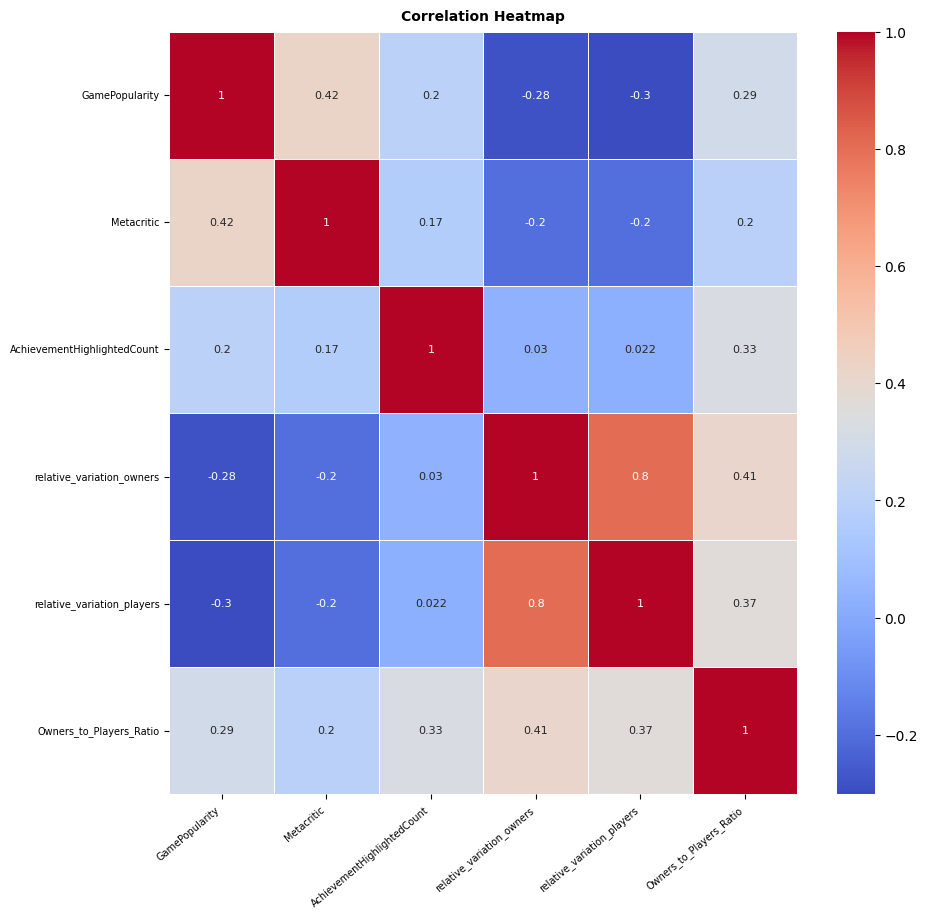


Adding Interaction Features...


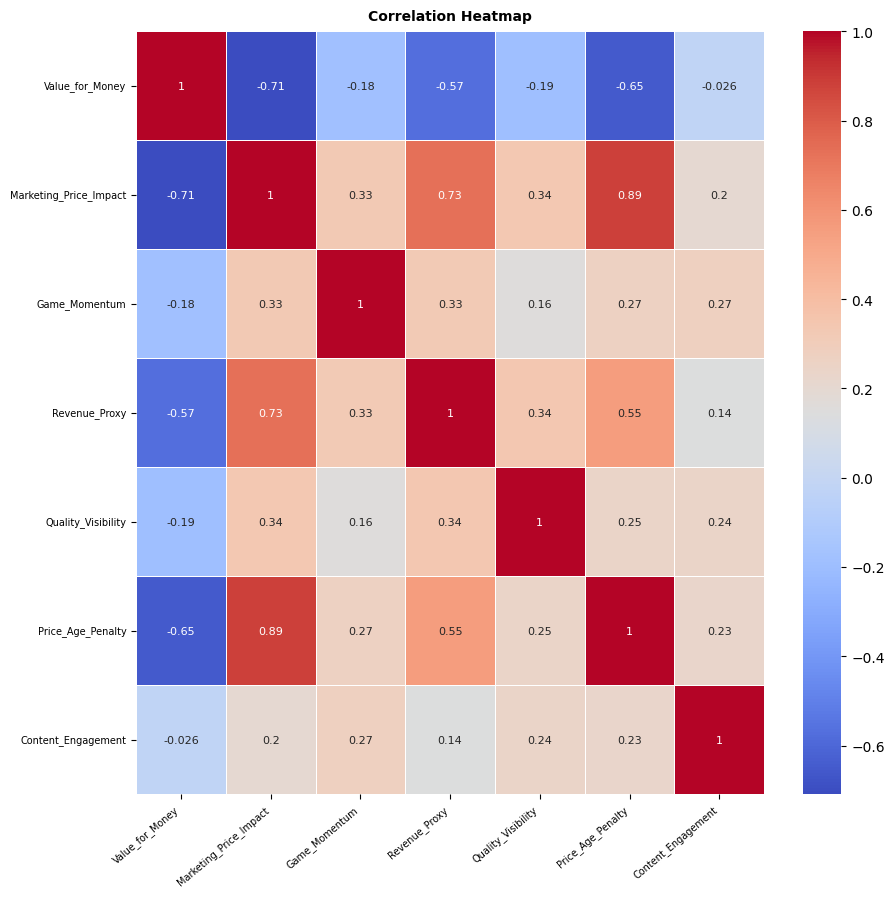


Starting Feature Filtering (Variance & Correlation)
Removed ['SubscriptionAvail', 'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'CategoryCoop', 'CategoryMMO', 'CategoryIncludeSrcSDK', 'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual', 'GenreIsStrategy', 'GenreIsRPG', 'GenreIsSimulation', 'GenreIsEarlyAccess', 'GenreIsFreeToPlay', 'GenreIsSports', 'GenreIsRacing', 'GenreIsMassivelyMultiplayer', 'PriceCurrency', 'HeaderImage', 'Linux_Storage_GB', 'Mac_Storage_GB', 'PC_Storage_GB'] , 
Removed 24 Zero/Low Variance Features.
Removed ['SteamSpyOwnersVariance', 'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance', 'FreeVerAvail', 'PurchaseAvail', 'PriceFinal', 'Background', 'DetailedDescrip', 'ScreenshotCount_Log', 'MovieCount_Log', 'Total_Media_Assets_log', 'Is_NonGame_Flag', 'Zero_Owners_Flag', 'PackageCount_Log', 'Achievement_Tier', 'AchievementCount_Log', 'Has_Discount', 'Engagement_Score', 'Review_Sentiment_Score', 'GameAge', 'Release_Quarter', 'Mac_OpenGL', 'Mar

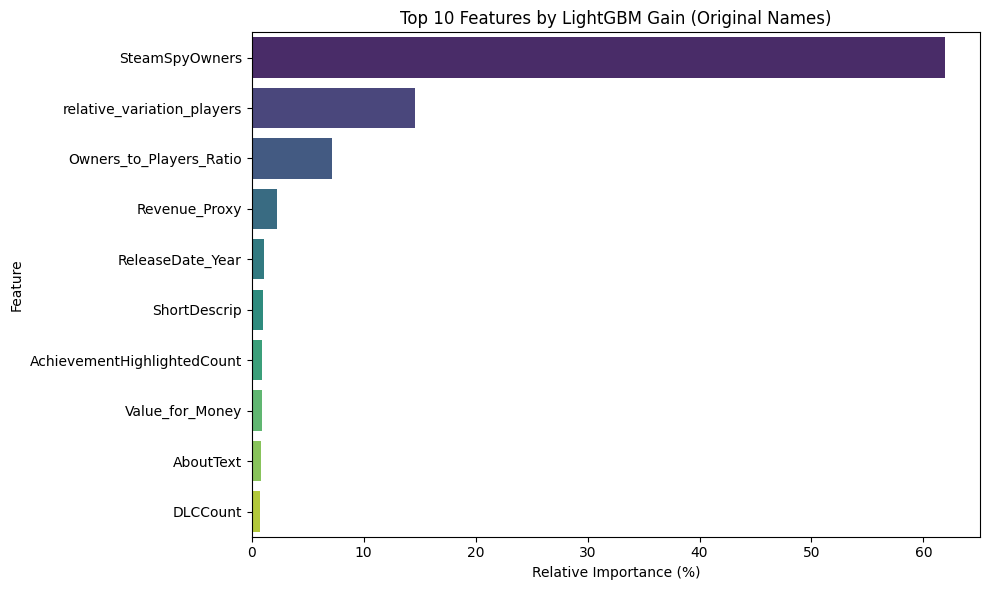

Selected Features: ['SteamSpyOwners', 'relative_variation_players', 'Owners_to_Players_Ratio', 'Revenue_Proxy', 'ReleaseDate_Year', 'ShortDescrip', 'AchievementHighlightedCount', 'Value_for_Money', 'AboutText', 'DLCCount']


In [11]:
# Load data
df = pd.read_csv('data2/train_data.csv')
df_processed = run_full_pipeline(df)

X = df_processed.drop(columns=['GamePopularity']).select_dtypes(include=[np.number]).fillna(0)
y = df_processed['GamePopularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
selected_features = lgbm_feature_selection(X_train,y_train)
print(f"Selected Features: {selected_features}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Random Forest Classification:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1874
           1       0.26      0.66      0.37       127
           2       0.84      0.86      0.85       271

    accuracy                           0.87      2272
   macro avg       0.70      0.80      0.72      2272
weighted avg       0.93      0.87      0.89      2272



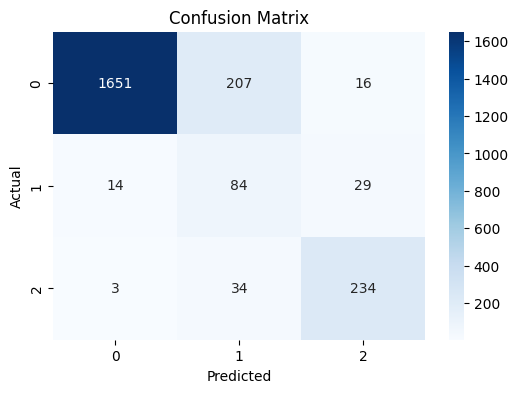

Accuracy Score: 86.6637323943662 %


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_scaled, y_train = smote_enn.fit_resample(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Classification:")
print(classification_report(y_test, y_pred))
# confusion matrix and accuracy score
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')   
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("Accuracy Score:", accuracy_score(y_test, y_pred)*100, "%")


SVM Classification:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1874
           1       0.24      0.77      0.36       127
           2       0.84      0.83      0.84       271

    accuracy                           0.84      2272
   macro avg       0.69      0.82      0.70      2272
weighted avg       0.93      0.84      0.87      2272



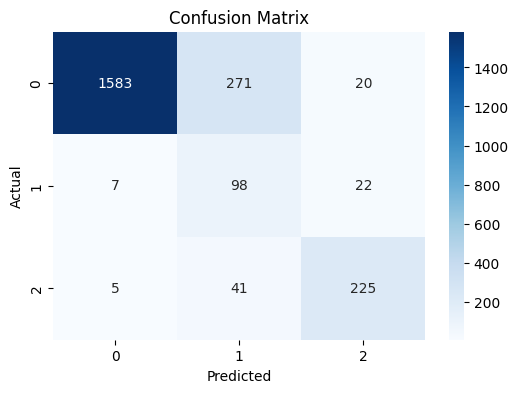

Accuracy Score: 83.89084507042254 %


In [13]:
# SVM model training

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import LinearSVC

svm_model = SVC (kernel='rbf',
    C=1,
    gamma = 'scale',
     class_weight='balanced',
    random_state=42
)


svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)


# Results
print("SVM Classification:")
print(classification_report(y_test, y_pred))

# Draw confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print("Accuracy Score:", accuracy_score(y_test, y_pred) * 100, "%")

In [14]:
import pickle
from sklearn.feature_selection import f_classif
from sklearn.neighbors import KNeighborsClassifier

K_FEATURES = 20   # keep top 20 features

selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_feature = X_train.columns[selected_mask].tolist()

print(f'Selected {len(selected_feature)} features:')
print(selected_feature)

X_train_sel = X_train[selected_feature]
X_test_sel  = X_test[selected_feature]

# Save selector
with open('selector_cls.pkl', 'wb') as f:
    pickle.dump(selector, f)
print('Saved selector_cls.pkl')


# Scaling for knn
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc  = scaler.transform(X_test_sel)

# Save scaler
with open('scaler_cls.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved scaler_cls.pkl')

## Hyper parameter tunning

# k neighbours
# k is changing , weight is constant ( uniform )
k_values = [3, 5, 7, 9, 11]
k_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', n_jobs=-1)
    knn.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_sc))
    k_results.append({'k': k, 'accuracy': acc})
    print(f'  k={k:2d} → Accuracy = {acc:.4f}')

k_df = pd.DataFrame(k_results)


# visualizing
plt.figure(figsize=(7, 4))
plt.plot(k_df['k'], k_df['accuracy'], marker='o', color='blue', linewidth=2)
plt.xticks(k_values)
plt.xlabel('n_neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN – Effect of n_neighbors (weights=uniform)')
plt.grid(True)
plt.tight_layout()
plt.show()


best_k = k_df.loc[k_df['accuracy'].idxmax(), 'k']
print(f'\nBest k = {best_k}')


## claude did this
def inv_sq(distances):
    """Custom weight: inverse-square of distance."""
    return 1 / (distances ** 2 + 1e-10)

weight_options = ['uniform', 'distance', inv_sq]
weight_labels  = ['uniform', 'distance', 'inv_sq']
w_results = []
# elmafrod it will choose best k value as a constant , then change the weight
for w, label in zip(weight_options, weight_labels):
    knn = KNeighborsClassifier(n_neighbors=int(best_k), weights=w, metric='minkowski', n_jobs=-1)
    knn.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_sc))
    w_results.append({'weights': label, 'accuracy': acc})
    print(f'  weights={label:12s} → Accuracy = {acc:.4f}')

w_df = pd.DataFrame(w_results)

plt.figure(figsize=(6, 4))
plt.bar(w_df['weights'], w_df['accuracy'], color=['blue', 'pink', 'green'])
plt.xlabel('Weights')
plt.ylabel('Test Accuracy')
plt.title(f'KNN – Effect of weights (k={int(best_k)})')
plt.ylim(0, 1)
for i, v in enumerate(w_df['accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


best_w_label = w_df.loc[w_df['accuracy'].idxmax(), 'weights']
best_w_func  = weight_options[weight_labels.index(best_w_label)]
print(f'\nBest weights = {best_w_label}')


ValueError: Found input variables with inconsistent numbers of samples: [9085, 21130]